# Mall Customers Segmentation


In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


### 1. Loading and Understanding the dataset 



#### 1.1 Loading the dataset

In [2]:
# Load the dataset
df = pd.read_csv('Mall_Customers.csv')

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### 1.2 Understanding the dataset 

In [4]:
print ('Shape: ', df.shape)
print('\nInfo: ')
print(df.info())
print('\nData types\n')
print(df.dtypes)



Shape:  (200, 5)

Info: 
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB
None

Data types

CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object


In [5]:
#Checking for missing values
print('\n Missing values: \n')
print(df.isnull().sum())


 Missing values: 

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [6]:
#Checking for dupplicates (rows)
print('\n Duplicates: \n')
print(df.duplicated().sum())


 Duplicates: 

0


#### 1.3 Statistical Summary

- Statistical summary is necessary for spoting anamolies, understanding data distribution and skewness, indentifying outliers along with guiding feature Scaling Features.

In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


#### 1.4 Categorical Column distribution 

- As this dataset contains categorical column like Gender, finding the distribution of categorical entries in the dataset here is useful for later k-means clustering purposes.

In [8]:
print('Gender distribution: \n')
print(df['Gender'].value_counts())

print('\nGender Percentage: \n')
print(df['Gender'].value_counts(normalize=True) * 100)

Gender distribution: 

Gender
Female    112
Male       88
Name: count, dtype: int64

Gender Percentage: 

Gender
Female    56.0
Male      44.0
Name: proportion, dtype: float64


#### 1.5 Summary 

- The Mall Customer Segmentation dataset has only 200 rows and 5 Columns: CustomerID, Gender, Age, AnnualIncome (K$) and Spending Score (1-100). 

- Here, Spending Score basically represents how much a cistomer spends, based on customer behavior and purchasing data. It directly helps us indentify the high-value vs low-value customers. 

- Gender is the categorical volumn in the datast with about 55% female and 44% male distribution. 

### 2. EDA (Exploratory Data Analysis)

#### 2.1 Distribution of Numeric Features 

- For viewing the shape of Age, Income and Spending Score to know if the features are skewed.

- It helps decided if scaling or transformation is needed later. 


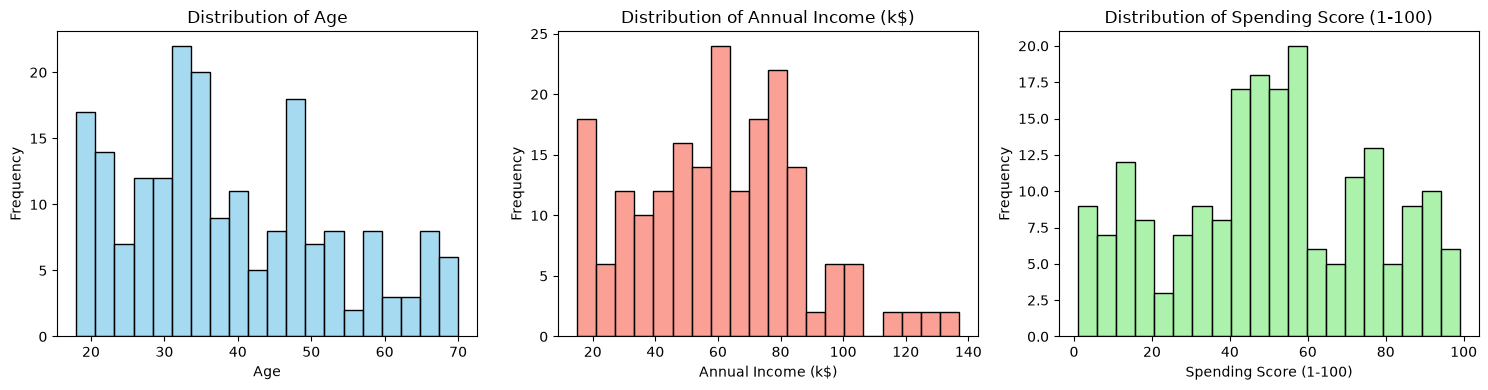

         Age  Annual Income (k$)  Spending Score (1-100)
count  200.0               200.0                   200.0
mean    38.8                60.6                    50.2
std     14.0                26.3                    25.8
min     18.0                15.0                     1.0
25%     28.8                41.5                    34.8
50%     36.0                61.5                    50.0
75%     49.0                78.0                    73.0
max     70.0               137.0                    99.0


In [9]:
# Histogram 

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
colors = ['skyblue', 'salmon', 'lightgreen']

for ax, col, color in zip(axes, cols, colors):
    sns.histplot(df[col], bins=20, ax=ax, color=color)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(df[cols].describe().round(1)) 
#viewing the statistical summary also gives a good insight into the distribution of the data.

#### 2.2 Gender Distribution 

- Using Pie chart for viewing gender split 
- Using Box plot for viewing spending score by gender

/var/folders/hq/j021gfw15kn44g4836jk8hh80000gn/T/ipykernel_66400/1204237890.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Gender', y='Spending Score (1-100)', ax=axes[1], palette='Set2')


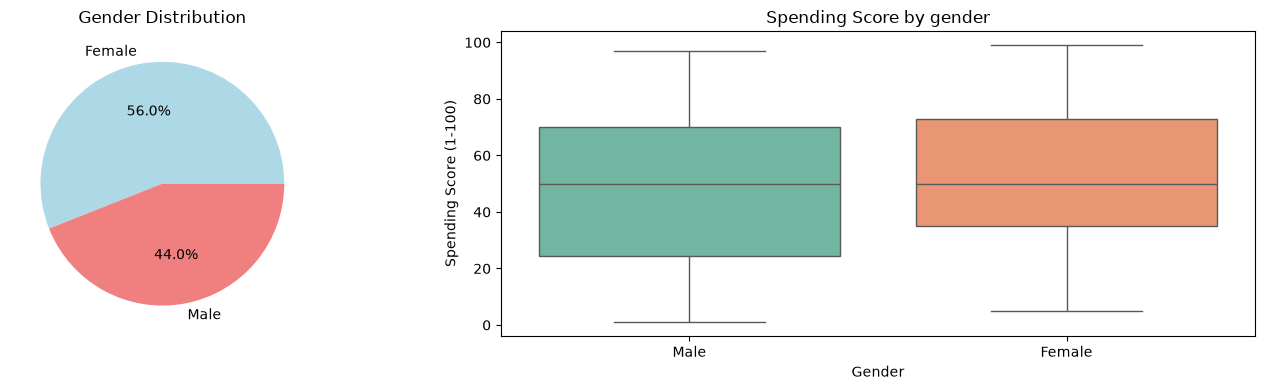

         Age  Annual Income (k$)  Spending Score (1-100)
Gender                                                  
Female  38.1                59.2                    51.5
Male    39.8                62.2                    48.5


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

#pie chart of gender split
gender_counts = df['Gender'].value_counts()

#axes[0] plots the pie chart on the first subplot
axes[0].pie(gender_counts, labels = gender_counts.index, autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
axes[0].set_title('Gender Distribution')

#spending score by gender
sns.boxplot(data=df, x='Gender', y='Spending Score (1-100)', ax=axes[1], palette='Set2')
axes[1].set_title('Spending Score by gender')

plt.tight_layout()
plt.show()

#Also viewing the average number count% of male and female in all the columns.
print(df.groupby('Gender')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1))

#### 2.3 Correrelation Heatmap

- In clustering, it is important to check the correlation between features to prevent distortion in distance based-clustering algorithms. 

For examples:  If the Age and Income features are highly correlated, this relationship will dominate the clusters formed, and neglects the other features in the dataset. 

- Heatmaps are used to visualize the correlation.

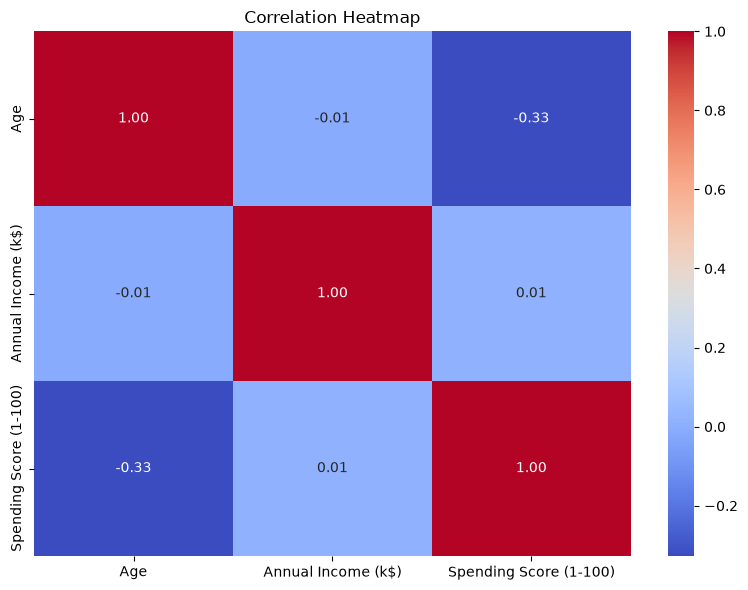


Key correlations:
Age vs Spending Score    : -0.327
Income vs Spending Score : 0.010
Age vs Income            : -0.012


In [11]:
numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


print("\nKey correlations:")
print(f"Age vs Spending Score    : {corr.loc['Age','Spending Score (1-100)']:.3f}")
print(f"Income vs Spending Score : {corr.loc['Annual Income (k$)','Spending Score (1-100)']:.3f}")
print(f"Age vs Income            : {corr.loc['Age','Annual Income (k$)']:.3f}")

#### 2.4 Scatterplot

- Pairing any two groups and finding their scatter plot. Here, I have used Income VS Spending Score and Age VS Spending Score on the basis of Gender Distribution. 


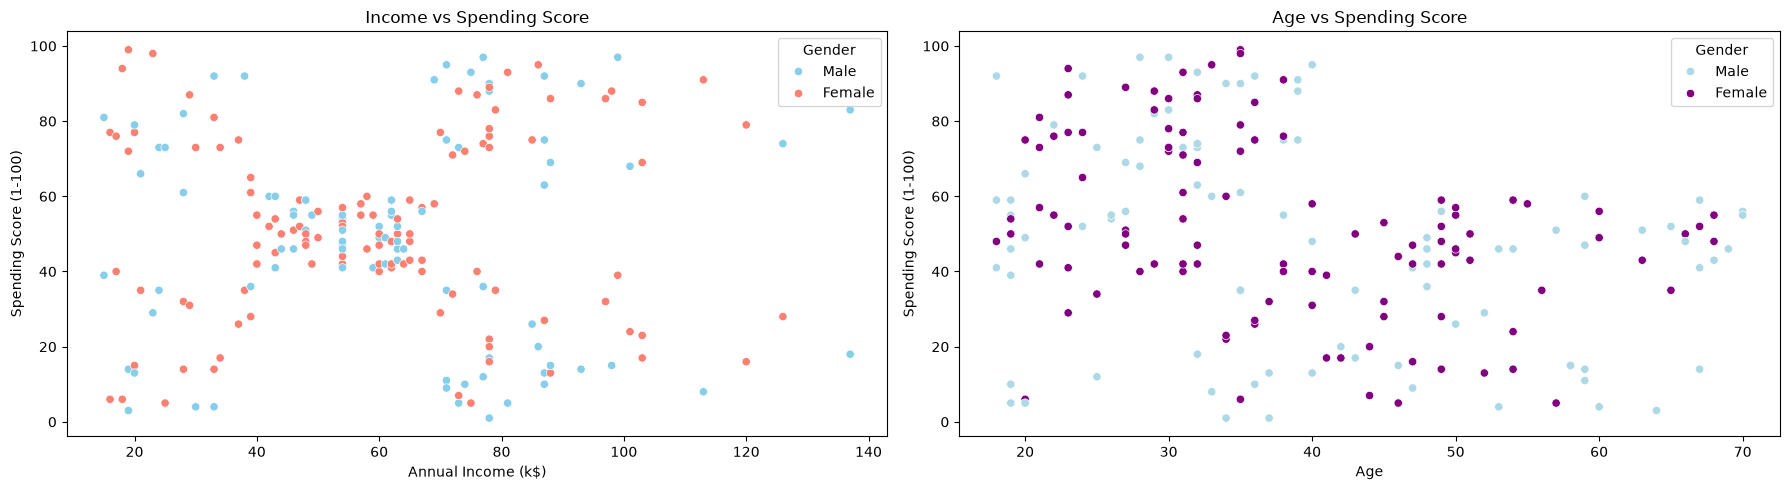

In [12]:
#Pairwise Scatterplot

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

#Income vs Spending Score
sns.scatterplot(data = df, x = 'Annual Income (k$)', y = 'Spending Score (1-100)',hue = 'Gender', ax = axes[0], palette=['skyblue', 'salmon'])
axes[0].set_title('Income vs Spending Score')


#Age vs Spending Score
sns.scatterplot(data=df, x = 'Age', y = 'Spending Score (1-100)', hue='Gender', palette = ['lightblue', 'purple'], ax = axes[1])
axes[1].set_title('Age vs Spending Score')


plt.tight_layout()
plt.show()

#### 2.5 Outlier Detection 

- !!!Important!!!, to ensure the clustering model is not pulled off track by extreme anamolies and noise. 

(-------------Viewing Ourliers for independent features---------------)

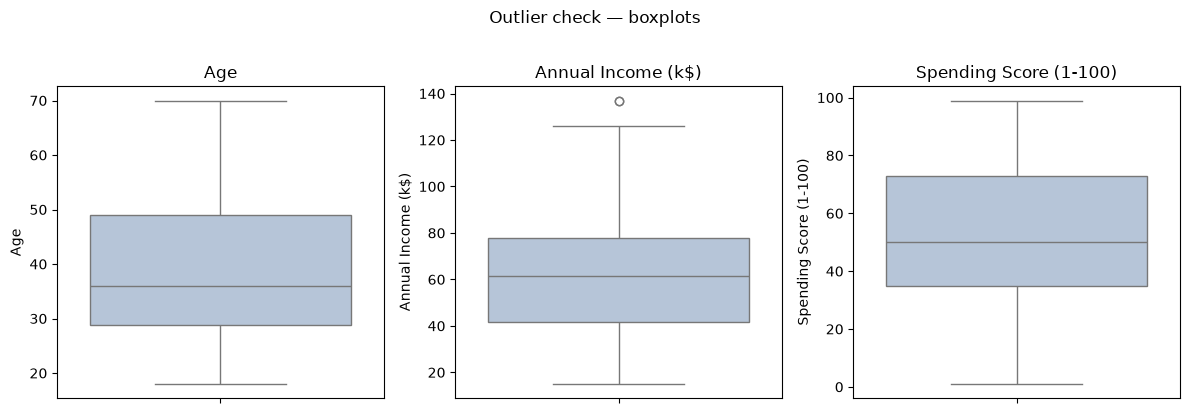

Age outliers: 0
Annual Income (k$) outliers: 2
Spending Score (1-100) outliers: 0


In [13]:
# Boxplots for outlier detection
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

for ax, col in zip(axes, cols):
    sns.boxplot(y=df[col], ax=ax, color='lightsteelblue')
    ax.set_title(f'{col}')

plt.suptitle('Outlier check — boxplots', y=1.02)
plt.tight_layout()
plt.show()

# IQR-based outlier count
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f'{col} outliers: {len(outliers)}')

#### 2.6 Spending patterns by groups

- Viewing the spending patterns on the basis of groups helps us connect out data back to the original objective of understanding different customer groups and developing marketing strategies 

- Grouped into differnet age bands(18-25, 25-35, ....)

- On the basis of their gender distribution

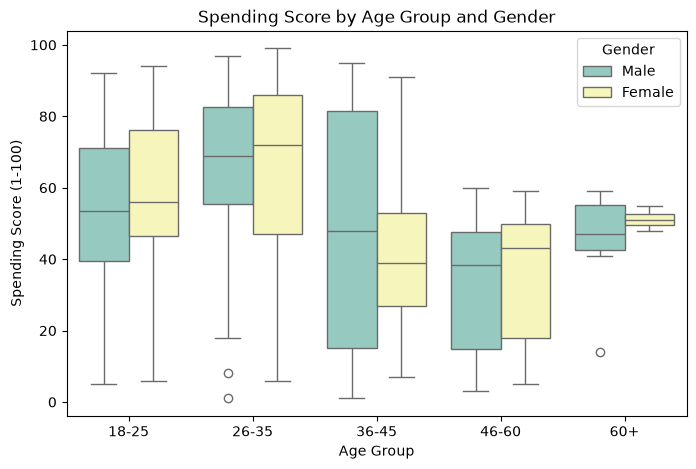

           Spending Score (1-100)
Age_Group                        
18-25                        54.9
26-35                        64.4
36-45                        44.8
46-60                        35.3
60+                          47.2


In [14]:
#Creating age bands
df['Age_Group'] = pd.cut(df['Age'], bins=[17, 25, 35, 45, 65, 70], labels=['18-25', '26-35', '36-45', '46-60', '60+'])

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Age_Group', y='Spending Score (1-100)', palette='Set3', hue = 'Gender')
plt.title('Spending Score by Age Group and Gender')
plt.xlabel('Age Group')
plt.ylabel('Spending Score (1-100)')
plt.show()


print(df.groupby('Age_Group')[['Spending Score (1-100)']].mean().round(1))


In [15]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Age_Group
0,1,Male,19,15,39,18-25
1,2,Male,21,15,81,18-25
2,3,Female,20,16,6,18-25
3,4,Female,23,16,77,18-25
4,5,Female,31,17,40,26-35


### 3. Data Preprocessing 

#### 3.1 Selecting features for Data Preprocessing

In [16]:
df_features = df[['Gender','Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

print('Features for clustering:\n') 
print(df_features.columns.tolist())
print(f'\nshape: {df_features.shape}')
df_features.head()

Features for clustering:

['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

shape: (200, 4)


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


#### 2.2 Encoding Gender

- Converting gender to numeric form : Female 0, Male 1

In [17]:
df_features['Gender'] = df_features['Gender'].map({'Female': 0, 'Male': 1})

print('Gender encoded: Female = 0, Male = 1')
print(df_features['Gender'].value_counts)
print(df_features.head())

Gender encoded: Female = 0, Male = 1
<bound method IndexOpsMixin.value_counts of 0      1
1      1
2      0
3      0
4      0
      ..
195    0
196    0
197    1
198    1
199    1
Name: Gender, Length: 200, dtype: int64>
   Gender  Age  Annual Income (k$)  Spending Score (1-100)
0       1   19                  15                      39
1       1   21                  15                      81
2       0   20                  16                       6
3       0   23                  16                      77
4       0   31                  17                      40


#### 3.3 Scaling numeric features

- Using Standard scaling for the given dataset as it is numeric and has different scales. Eg: Age ranges 18-70, Income 15-140 K($) and Spending Score (1-100). 

- Standard scaling puts all the feautres in the same scale(mean 0, standard deviation 1).

- In Standard Scaling :

    - A SCALE of 0 means, the orginal value was exactly AVERAGE.
    - A SCALE of 1 means, the original value was 1.5 STD ABOVE AVERAGE.
    - A scale of -2.0 means, the original value was 2 STD BELOW AVERAGE.

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
Scaler  = StandardScaler()

#scale all features to have mean = 0 and std = 1
x_scaled = Scaler.fit_transform(df_features)
x_scaled_df = pd.DataFrame(x_scaled, columns=df_features.columns)


print('Before Scaling:\n')
print(df_features.describe().round(1).loc[['mean', 'std']])

print('\nAfter Scaling:\n')
print(x_scaled_df.describe().round(2).loc[['mean', 'std']])

Before Scaling:

      Gender   Age  Annual Income (k$)  Spending Score (1-100)
mean     0.4  38.8                60.6                    50.2
std      0.5  14.0                26.3                    25.8

After Scaling:

      Gender  Age  Annual Income (k$)  Spending Score (1-100)
mean     0.0 -0.0                -0.0                    -0.0
std      1.0  1.0                 1.0                     1.0


#### 3.4 Organizing Feature sets

- Putting features in sets for clustering. 2D and ALL

- 2D (Income VS Spending Score) and ALL().




In [20]:
# Set A: 2D - Income and Spending Score only (easy to visualize)
X_2d = x_scaled_df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Set B: Full - all 4 features (Gender, Age, Income, Spending)
X_full = x_scaled_df.values

print(f"X_2d shape   : {X_2d.shape}   -> Income, Spending Score")
print(f"X_full shape : {X_full.shape} -> Gender, Age, Income, Spending Score")

X_2d shape   : (200, 2)   -> Income, Spending Score
X_full shape : (200, 4) -> Gender, Age, Income, Spending Score


In [21]:
# verifying before Clustering 

print("=== NaN check ===")
print(f"X_2d NaNs   : {np.isnan(X_2d).sum()}")
print(f"X_full NaNs : {np.isnan(X_full).sum()}")

print("\n=== Value ranges (min, max) ===")
print(f"X_2d   min: {X_2d.min():.2f}, max: {X_2d.max():.2f}")
print(f"X_full min: {X_full.min():.2f}, max: {X_full.max():.2f}")

print("\n=== Ready for cluster count ===")

=== NaN check ===
X_2d NaNs   : 0
X_full NaNs : 0

=== Value ranges (min, max) ===
X_2d   min: -1.91, max: 2.92
X_full min: -1.91, max: 2.92

=== Ready for cluster count ===


### 4. Applying K-means Clustering 

- K-means Clustering is an unsupervised machine learning algorithm, that splits the dataset into K distinct, non-overlappiong group also called clusters based on bow similar the data points to one another.

- It only looks at the geometric distance between fetures to find hidden patterns and naturally group the data. 

- Must know;
    - K means finds the center point of the groups-called centroids-and assigns every data point closest to its centroid. 

    - The algorithm then minimizes the distance between the data points and their respective centers, optimizing for tight, compact clusters. 

#### 4.1 Finding the optimal numbers of clusters

- Before applying k-means it is necessary to find the optimal number of clusters.

- Using Elbow method and Silhouette Score.


#### Elbow Method

- Is concerned with "Are the data points (centroids) within each cluster close to their center?", focuses on closeness/tightness of clusters. 

- It tracks WCSS (Within Cluster Sum of Squares) / INERTIA, which will always drop as the center point gets close to the data..... We look for INFLECTION POINT here where the rapid drop suddenly slows down, forming and ELBOW

In [22]:
from sklearn.cluster import KMeans

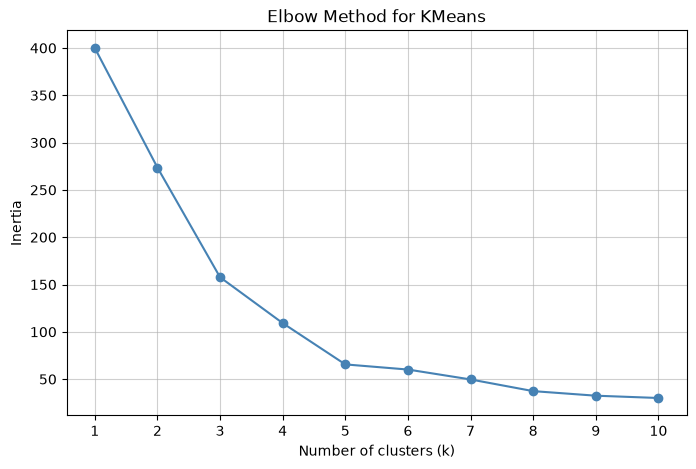

In [23]:
# Elbow method for KMeans clustering

inertia = []
k_range = range(1, 11)

for k in k_range:

    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_2d) #X_2d the previously defined 2D dataset (Income VS Spending Score)
    inertia.append(km.inertia_)

# later other features will be added and checked if it fits the clusters in this x_2d dataset.



plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.title('Elbow Method for KMeans')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True, alpha=0.6)
plt.show()


In [24]:
print("Inertia vlaues:")
for k, inertia_value in zip(k_range, inertia):
    print(f"k={k}: Inertia={inertia_value:.2f}")

Inertia vlaues:
k=1: Inertia=400.00
k=2: Inertia=273.67
k=3: Inertia=157.70
k=4: Inertia=109.23
k=5: Inertia=65.57
k=6: Inertia=60.13
k=7: Inertia=49.67
k=8: Inertia=37.32
k=9: Inertia=32.50
k=10: Inertia=30.06


#### Sillhouette Score

- Unlike elbow method which is concerned with only the closeness of clusters, but is also concerened with "How far apart clusters are from each other". 

- Sillhouette method prevents one from creating overlapping groups. 

- This method scores every data point form -1 to +1.
    
    - +1(Perfect)
    - 0 (Boundary - Point Sits on Boundary between clsuters)
    - -1(Wrong group)

- Look for highest peak score instead of elbow.


In [25]:
from sklearn.metrics import silhouette_score

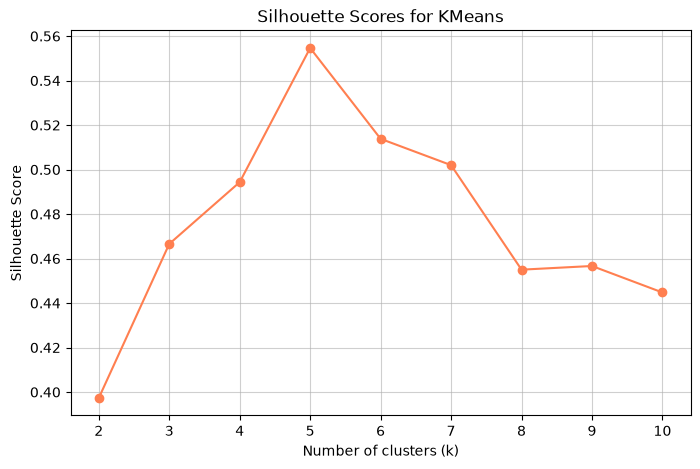

In [26]:
# Silhouette scores for KMeans clustering

silhouette_scores = []
k_range_silhouette = range(2, 11) # k must be >=2. 

for k in k_range_silhouette:
    km = KMeans(n_clusters=k, random_state=42)
    cluster_labels = km.fit_predict(X_2d)
    score = silhouette_score(X_2d, cluster_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_range_silhouette, silhouette_scores, marker='o', color='coral')
plt.title('Silhouette Scores for KMeans')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range_silhouette)
plt.grid(True, alpha=0.6)
plt.show()

In [27]:
print("Silhouette scores:")
for k, score in zip(k_range_silhouette, silhouette_scores):
    print(f"k={k}: Silhouette Score={score:.3f}")


best_k = k_range_silhouette[np.argmax(silhouette_scores)]
print(f"\nBest k based on silhouette score: {best_k}")

Silhouette scores:
k=2: Silhouette Score=0.397
k=3: Silhouette Score=0.467
k=4: Silhouette Score=0.494
k=5: Silhouette Score=0.555
k=6: Silhouette Score=0.514
k=7: Silhouette Score=0.502
k=8: Silhouette Score=0.455
k=9: Silhouette Score=0.457
k=10: Silhouette Score=0.445

Best k based on silhouette score: 5


#### 4.2 Final Decision (SIdebySide Comparison)

- ELBOW MTHOD vs SILOHOUETTE SCORE

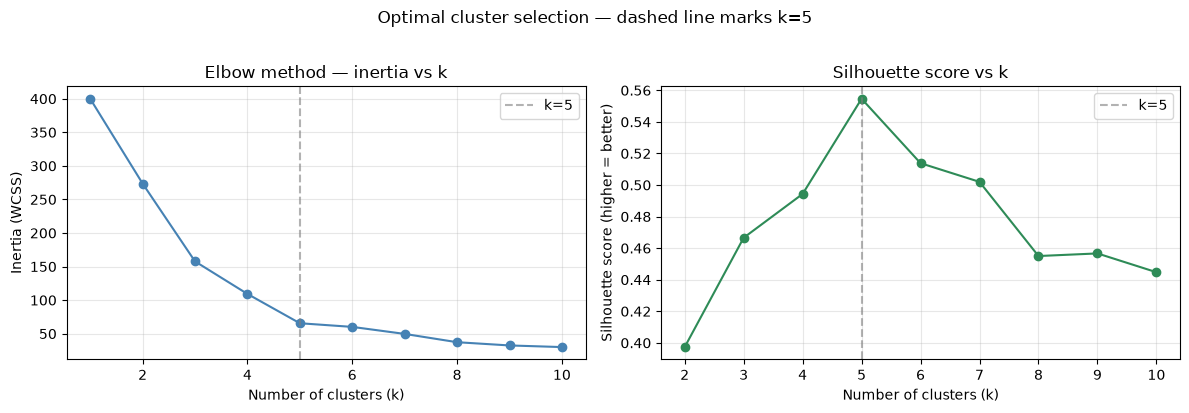


=== DECISION: k = 5 ===
Both metrics agree on k=5:
  - Elbow method shows a clear bend at k=5
  - Silhouette score peaks at k=5 (0.5547)


In [28]:
# Combining Elbow and Silhouette results

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow plot
axes[0].plot(list(k_range), inertia, marker='o', color='steelblue')
axes[0].set_title('Elbow method — inertia vs k')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].axvline(5, color='gray', linestyle='--', alpha=0.6, label='k=5')
#insertig line on the elbow that is 5.
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(list(k_range_silhouette), silhouette_scores, marker='o', color='seagreen')
axes[1].set_title('Silhouette score vs k')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score (higher = better)')
axes[1].axvline(5, color='gray', linestyle='--', alpha=0.6, label='k=5')
#inserting line on the highest peak point that is 5.
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Optimal cluster selection — dashed line marks k=5', y=1.02)
plt.tight_layout()
plt.show()



# Final decision
OPTIMAL_K = 5
print(f"\n=== DECISION: k = {OPTIMAL_K} ===")
print("Both metrics agree on k=5:")
print("  - Elbow method shows a clear bend at k=5")
print(f"  - Silhouette score peaks at k=5 ({max(silhouette_scores):.4f})")

### 5. Training and Visualizing the model + Applying DBSCAN for all features.

#### 5.1 Training KMeans  

- Training for x_2d (Income vs Spending Score (1-100)) 

In [29]:
from sklearn.cluster import KMeans

#since optimal_k = 5

# Training Kmeans with the optimal_k
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42)
kmeans.fit(X_2d)

# Adding cluster labels on original dataframe
df['KMeans_Cluster'] = kmeans.labels_

print(f"\nCluster Sizes")
print(df['KMeans_Cluster'].value_counts().sort_index())



Cluster Sizes
KMeans_Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


#### 5.2 Visualizing KMeans Clusters 

- Using Scatter plot

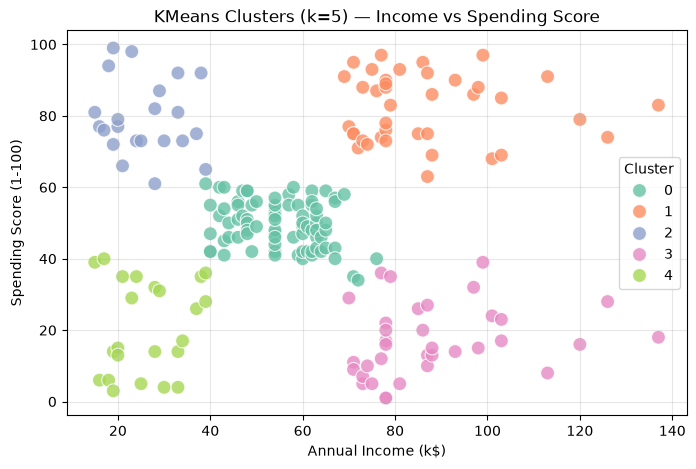

In [30]:
# Visualize the clusters in 2D (Income vs Spending Score)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='KMeans_Cluster', palette='Set2', s=100, alpha=0.8)
plt.title('KMeans Clusters (k=5) — Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()



#### 5.3 Applying DBSCAN

- DBSCAN stands for Dentsity-Based Spatial Clustering of Applications with Noise. 

- DBSCAN is a method in clustering that groups data points absed how densely packed they are in the future space. 

.
.
.

Why DBSCAN?

- DBSCAN includes the  left out features Age and Gender in the KMeans Clustering. 

- Also, KMeans here has one fundamental limitaion, it must assign every single customer to a cluster whether they belong there or not.

- DBSACN solves this problem by indentifying those unsual customers as noise rather than forcing them in somewhere they don't belong.

#### 5.3.1 Training DBSCAN

- eps (epsilion) : radius of the neighbourhood circle around a data point. Determines how close two points must be to be considered neighbors.

- min_samples: minimum of data points the must sit inside that "eps" to declare neighbour as high_density area. 

In [31]:
from sklearn.cluster import DBSCAN

In [32]:
# Applying DBSCAN on all Feature set (Gender, Age, Income, Spending Score)
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_full)

df['DBSCAN_Cluster'] = dbscan_labels

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_dbscan = list(dbscan_labels).count(-1)

print(f"\nDBSCAN Clusters (eps=0.5, min_samples=5):")
print(f"Number of clusters (excluding noise): {n_clusters_dbscan}")
print(f"Number of noise points: {n_noise_dbscan}")



DBSCAN Clusters (eps=0.5, min_samples=5):
Number of clusters (excluding noise): 9
Number of noise points: 105


#### 5.3.2 Visualizing DBSCAN 

- Visualization of the 4D points on the 2D plot is not possible so we need to convert the 4D poits into 2D points for visualization. 

- Using dimiensionality reduction such as PCA (Principal Compoment Analysis). 

In [33]:
from sklearn.decomposition import PCA

# Reduce X_full from 4D to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_full)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total variance captured  : {sum(pca.explained_variance_ratio_)*100:.1f}%")

Variance explained by PC1: 33.7%
Variance explained by PC2: 26.2%
Total variance captured  : 59.9%


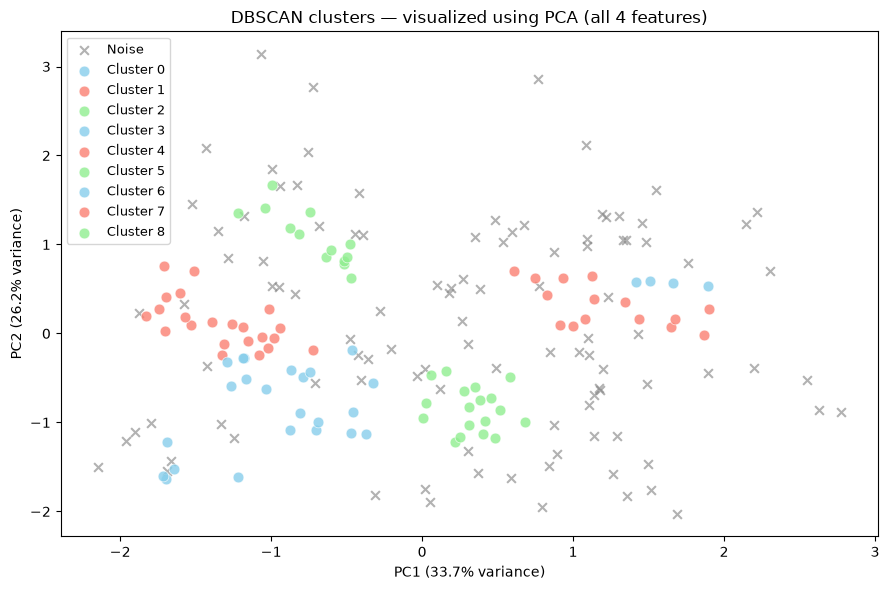

In [34]:
#Visualizing DBSCAN on PCA-reduced axes

fig, ax = plt.subplots(figsize=(9, 6))

# Noise points
noise = df['DBSCAN_Cluster'] == -1
ax.scatter(
    X_pca[noise, 0], X_pca[noise, 1],
    c='gray', label='Noise', marker='x', s=40, alpha=0.6
)

# Clusters
for label in sorted(set(dbscan_labels) - {-1}):
    mask = dbscan_labels == label
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[label % len(colors)],
        label=f'Cluster {label}',
        s=60, alpha=0.8, edgecolors='white', linewidths=0.5
    )

ax.set_title('DBSCAN clusters — visualized using PCA (all 4 features)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


### 6. Evaluating and Analyzing the Clusters


#### 6.1 Cluster Profiles

-  Giving cluster their own specific profile/ description.

In [35]:
# Cluster profiles
profile = df.groupby('KMeans_Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean().round(1)

# Assigning segment names based on profile

segment_names = {
    0: 'Average Customer',
    1: 'High Income, High Spender',
    2: 'Young, Low Income, High Spender',
    3: 'High Income, Low Spender',
    4: 'Middle-Aged, Low Income, Low Spender'
}

profile['Segment Name'] = profile.index.map(segment_names)
print(profile.to_string())

                 Age  Annual Income (k$)  Spending Score (1-100)                          Segment Name
KMeans_Cluster                                                                                        
0               42.7                55.3                    49.5                      Average Customer
1               32.7                86.5                    82.1             High Income, High Spender
2               25.3                25.7                    79.4       Young, Low Income, High Spender
3               41.1                88.2                    17.1              High Income, Low Spender
4               45.2                26.3                    20.9  Middle-Aged, Low Income, Low Spender


#### 6.2 Feature Heatmap

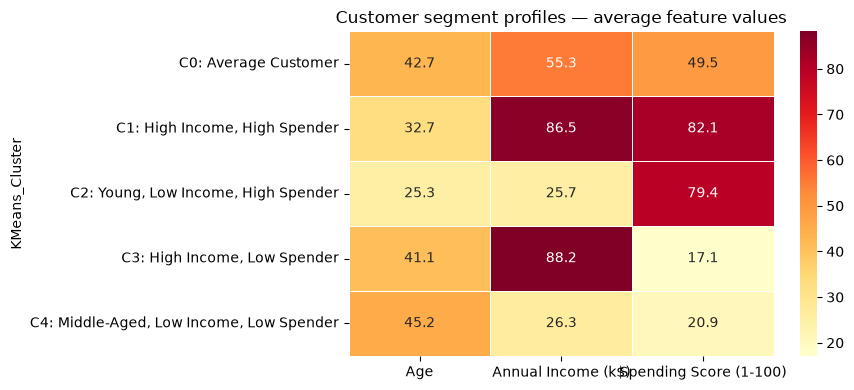

In [36]:
fig, ax = plt.subplots(figsize=(9, 4))

sns.heatmap(
    profile[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']],
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    yticklabels=[f"C{i}: {segment_names[i]}" for i in range(5)]
)
ax.set_title('Customer segment profiles — average feature values')
plt.tight_layout()
plt.show()

### 7. Final Business Summary -  BUSINESS RECOMMENDATIONS

In [37]:
print("=" * 60)
print("  CUSTOMER SEGMENTATION — BUSINESS RECOMMENDATIONS")
print("=" * 60)

summary = [
    ("High Income, High Spender", "33 yrs, 87k income, score 82",
     "Your most valuable segment. Invest heavily in VIP retention programs and exclusive perks. Every churned customer here is maximum revenue loss."),

    ("Young, Low Income, High Spender", "25 yrs, 26k income, score 79",
     "High engagement despite low income. Build brand loyalty now through social media and affordable trendy products. As their income grows, they become your next top segment."),

    ("High Income, Low Spender", "41 yrs, 88k income, score 17",
     "Biggest untapped opportunity. They have the money but aren't spending it. Target with premium quality messaging and exclusive incentives to unlock their potential."),

    ("Average Customer", "43 yrs, 55k income, score 50",
     "Your stable base. Use loyalty programs and seasonal upselling to gradually shift them toward higher spending. Small improvements here multiply across the largest group."),

    ("Middle-Aged, Low Income, Low Spender", "45 yrs, 26k income, score 21",
     "Price-sensitive and disengaged. Focus on essentials, clearance deals, and budget campaigns. Don't over-invest — keep them retained at low cost."),
]

for i, (name, profile, recommendation) in enumerate(summary, 1):
    print(f"\n{i}. {name}")
    print(f"   Profile       : {profile}")
    print(f"   Recommendation: {recommendation}")

print(f"\n{'='*60}")
print(f"  DBSCAN identified {(dbscan_labels == -1).sum()} outlier customers")
print(f"  who don't fit any segment — handle individually.")
print(f"{'='*60}")

  CUSTOMER SEGMENTATION — BUSINESS RECOMMENDATIONS

1. High Income, High Spender
   Profile       : 33 yrs, 87k income, score 82
   Recommendation: Your most valuable segment. Invest heavily in VIP retention programs and exclusive perks. Every churned customer here is maximum revenue loss.

2. Young, Low Income, High Spender
   Profile       : 25 yrs, 26k income, score 79
   Recommendation: High engagement despite low income. Build brand loyalty now through social media and affordable trendy products. As their income grows, they become your next top segment.

3. High Income, Low Spender
   Profile       : 41 yrs, 88k income, score 17
   Recommendation: Biggest untapped opportunity. They have the money but aren't spending it. Target with premium quality messaging and exclusive incentives to unlock their potential.

4. Average Customer
   Profile       : 43 yrs, 55k income, score 50
   Recommendation: Your stable base. Use loyalty programs and seasonal upselling to gradually shift them t

In [38]:
df.to_csv('Final_Mall_Customers_Segmented.csv', index=False)

# External APP

In [39]:
import joblib

joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(Scaler, 'scaler.pkl')

['scaler.pkl']